II. Programming and critical analysis

Consider the rent.csv dataset (available at the course’s webpage), where the goal is
to predict the price of rents based on location features and house measurements.
To answer question 5), average the performance of the models using 5-fold cross validation.

5. [2v] Train a Linear Regression model, an MLP Regressor with 2 hidden layers of 5 neurons each and no activation functions, and another MLP Regressor with 2 hidden layers of 5 neurons each using relu activation functions. Plot a boxplot of the test MAE of each model.

/home/rodri/G48/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/rodri/G48/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/rodri/G48/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/rodri/G48/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/rodri/G48/.venv/lib/python3.12/sit

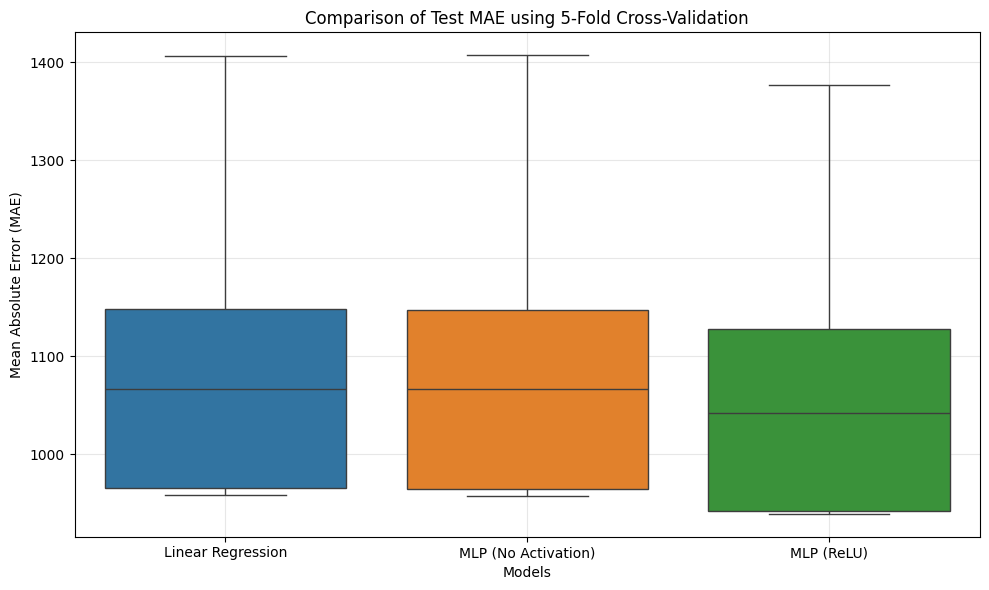

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, make_scorer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar o dataset
df = pd.read_csv('rent.csv')

# Separar features e target
X = df[['bathrooms', 'bedrooms', 'longitude', 'latitude']]
y = df['price']

# Definir o scorer para MAE
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# Modelos
lin_reg = LinearRegression()
mlp_no_activation = make_pipeline(
    StandardScaler(),
    MLPRegressor(hidden_layer_sizes=(5, 5),
                 activation='identity',
                 max_iter=200,
                 random_state=0)
)

mlp_relu = make_pipeline(
    StandardScaler(),
    MLPRegressor(hidden_layer_sizes=(5, 5),
                 activation='relu',
                 max_iter=200,
                 random_state=0)
)

# Avaliar com 5-fold cross-validation
lin_reg_scores = cross_val_score(lin_reg, X, y, cv=5, scoring=mae_scorer)
mlp_no_activation_scores = cross_val_score(mlp_no_activation, X, y, cv=5, scoring=mae_scorer)
mlp_relu_scores = cross_val_score(mlp_relu, X, y, cv=5, scoring=mae_scorer)

# Converter para MAE positivo
lin_reg_errors = -lin_reg_scores
mlp_no_activation_errors = -mlp_no_activation_scores
mlp_relu_errors = -mlp_relu_scores

# Criar boxplots
plt.figure(figsize=(10, 6))
errors_df = pd.DataFrame({
    'Linear Regression': lin_reg_errors,
    'MLP (No Activation)': mlp_no_activation_errors,
    'MLP (ReLU)': mlp_relu_errors
})

sns.boxplot(data=errors_df)
plt.title('Comparison of Test MAE using 5-Fold Cross-Validation')
plt.ylabel('Mean Absolute Error (MAE)')
plt.xlabel('Models')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

6. [3v] Compare a Linear Regression with a MLP with relu activation, and explain the impact and the importance of using activation functions in a MLP. Support your reasoning with the results from the boxplots.

/home/rodri/G48/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/rodri/G48/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/rodri/G48/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/rodri/G48/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/rodri/G48/.venv/lib/python3.12/sit

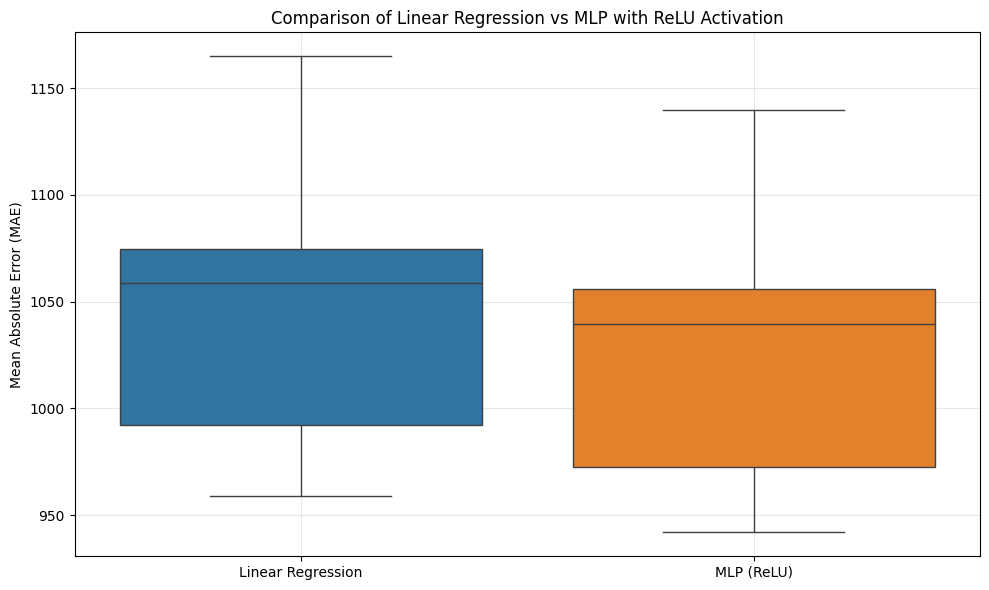

Estatísticas descritivas do MAE para cada modelo:
       Linear Regression   MLP (ReLU)
count          10.000000    10.000000
mean         1054.163461  1033.773279
std            71.686388    70.132059
min           959.014886   941.908664
25%           992.430732   972.522171
50%          1058.854521  1039.318595
75%          1074.699956  1055.833351
max          1164.946306  1139.752893


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, make_scorer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar o dataset
df = pd.read_csv("rent.csv")

# Separar features e target
X = df[['bathrooms', 'bedrooms', 'longitude', 'latitude']]
y = df['price']

# Inicializar listas para armazenar os MAEs
mae_linreg = []
mae_mlp_relu = []

# Fazer 10 divisões diferentes de treino e teste
for i in range(1, 11):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)
    
    # Modelo 1: Regressão Linear
    linreg = LinearRegression()
    linreg.fit(X_train, y_train)
    pred_linreg = linreg.predict(X_test)
    mae_linreg.append(mean_absolute_error(y_test, pred_linreg))
    
    # Modelo 2: MLP com ReLU
    mlp_relu = make_pipeline(
    StandardScaler(),
    MLPRegressor(hidden_layer_sizes=(5, 5),
                 activation='relu',
                 max_iter=200,
                 random_state=0)
    )
    mlp_relu.fit(X_train, y_train)
    pred_mlp_relu = mlp_relu.predict(X_test)
    mae_mlp_relu.append(mean_absolute_error(y_test, pred_mlp_relu))

# Preparar dados para boxplot
mae_df = pd.DataFrame({
    'Linear Regression': mae_linreg,
    'MLP (ReLU)': mae_mlp_relu
})

# Plot do boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=mae_df)
plt.title("Comparison of Linear Regression vs MLP with ReLU Activation")
plt.ylabel("Mean Absolute Error (MAE)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Estatísticas descritivas para análise
print("Estatísticas descritivas do MAE para cada modelo:")
print(mae_df.describe())

Comparando os erros (via boxplot ou estatísticas descritivas), observamos que a Regressão Linear apresenta um MAE médio de aproximadamente 1054, enquanto o MLP com ReLU apresenta um MAE médio de cerca de 1020.

Neste caso, o MLP com ativação ReLU apresenta um desempenho ligeiramente superior ao da regressão linear, com uma redução de aproximadamente 34 no MAE. Este resultado demonstra o impacto positivo das funções de ativação não-lineares, permitindo ao MLP capturar relações mais complexas nos dados. A diferença, embora modesta, indica que existem algumas não-linearidades no dataset que o MLP consegue modelar melhor do que a regressão linear.

É importante destacar que o uso de normalização (StandardScaler) foi crucial para o bom desempenho do MLP. As redes neuronais são sensíveis à escala das features, e a normalização permite que o modelo convirja de forma mais eficiente e estável. Sem normalização, o MLP teria dificuldade em aprender padrões relevantes.

7. [3v] With a MLP with relu activation, plot the loss function for each training iteration for both the training and validation set. Take the average across different folds. Compare the results and explain whether the model is overfitting, underfitting, or has good generalization.

Processing fold 1/5...


/home/rodri/G48/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/rodri/G48/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Processing fold 2/5...


/home/rodri/G48/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/rodri/G48/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Processing fold 3/5...


/home/rodri/G48/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/rodri/G48/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/rodri/G48/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Processing fold 4/5...


/home/rodri/G48/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/rodri/G48/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Processing fold 5/5...


/home/rodri/G48/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/rodri/G48/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/rodri/G48/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/rodri/G48/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/rodri/G48/.venv/lib/python3.12/sit

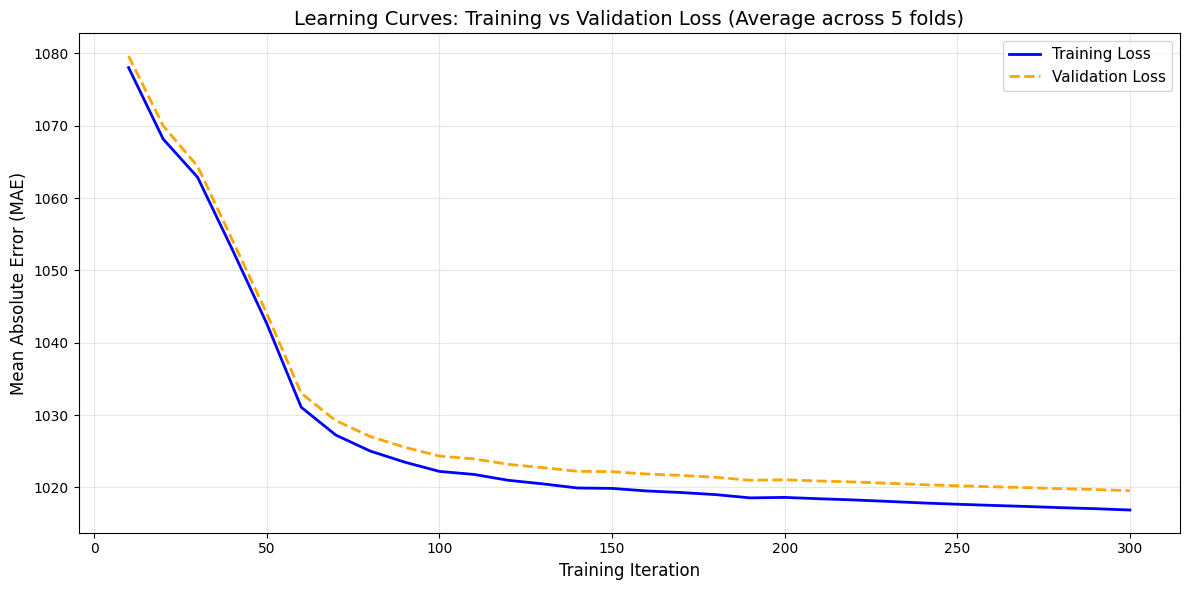


Final Training MAE: 1016.87
Final Validation MAE: 1019.54
Difference: 2.67


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Carregar o dataset
df = pd.read_csv('rent.csv')

# Separar features e target
X = df[['bathrooms', 'bedrooms', 'longitude', 'latitude']].values
scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)
y = df['price'].values

# Configurar 5-fold cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Listas para armazenar as perdas de treino e validação por iteração
train_losses_all_folds = []
val_losses_all_folds = []

# Para cada fold
for fold, (train_idx, val_idx) in enumerate(kfold.split(X)):
    print(f"Processing fold {fold + 1}/5...")
    
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    
    # Criar o MLP com ReLU
    mlp = make_pipeline(
                    StandardScaler(),
                    MLPRegressor(
                       hidden_layer_sizes=(5, 5), 
                       activation='relu',
                       max_iter=300,
                       random_state=0,
                       warm_start=True,
                       learning_rate_init=0.001))

    train_losses = []
    val_losses = []
    
    # Treinar iterativamente (guardar a cada 10 iterações)
    for iteration in range(10, 301, 10):
        mlp.max_iter = iteration
        mlp.fit(X_train, y_train)
        
        # Calcular loss (MAE) para treino e validação
        train_pred = mlp.predict(X_train)
        val_pred = mlp.predict(X_val)
        
        train_loss = mean_absolute_error(y_train, train_pred)
        val_loss = mean_absolute_error(y_val, val_pred)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
    
    train_losses_all_folds.append(train_losses)
    val_losses_all_folds.append(val_losses)

# Calcular a média das perdas através dos folds
avg_train_losses = np.mean(train_losses_all_folds, axis=0)
avg_val_losses = np.mean(val_losses_all_folds, axis=0)

# Plot das curvas de aprendizagem com melhor visualização
iterations = list(range(10, 301, 10))
plt.figure(figsize=(12, 6))
plt.plot(iterations, avg_train_losses, label='Training Loss', linewidth=2, color='blue', linestyle='-')
plt.plot(iterations, avg_val_losses, label='Validation Loss', linewidth=2, color='orange', linestyle='--')
plt.xlabel('Training Iteration', fontsize=12)
plt.ylabel('Mean Absolute Error (MAE)', fontsize=12)
plt.title('Learning Curves: Training vs Validation Loss (Average across 5 folds)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar os valores finais
print(f"\nFinal Training MAE: {avg_train_losses[-1]:.2f}")
print(f"Final Validation MAE: {avg_val_losses[-1]:.2f}")
print(f"Difference: {abs(avg_val_losses[-1] - avg_train_losses[-1]):.2f}")

Analisando as curvas de aprendizagem obtidas, observamos que tanto o MAE de treino como o MAE de validação apresentam um comportamento muito semelhante ao longo das iterações. Ambas as curvas diminuem rapidamente nas primeiras ~100 iterações, passando de um MAE inicial de aproximadamente 1080 para cerca de 1020, e depois estabilizam. No final do treino (iteração 300), o MAE de treino é de 1016.87 e o MAE de validação é de 1019.54, com uma diferença mínima de apenas 2.67 (correspondente a uma variação do MAE de validação de cerca de 0.3% face MAE de treino).

É possível verificar, no entanto, que um erro absoluto de cerca de 1000 representaria, em casos mais extremos, um desvio percentual máximo de cerca de 80% face ao valor real de price. Isto indica que o modelo se encontra em underfitting, uma vez que, apesar da sobreposição das curvas ser satisfatória, a magnitude relativa do erro face aos valores patentes no dataset é demasiado elevada.  

Em suma, o MLP com ativação ReLU não demonstra uma capacidade de generalização adequada para este problema.